Imbalaced dataset from CampusX link->https://youtu.be/yh2AKoJCV3k?si=gFe7G2qkV188LaMh

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
import pandas as pd

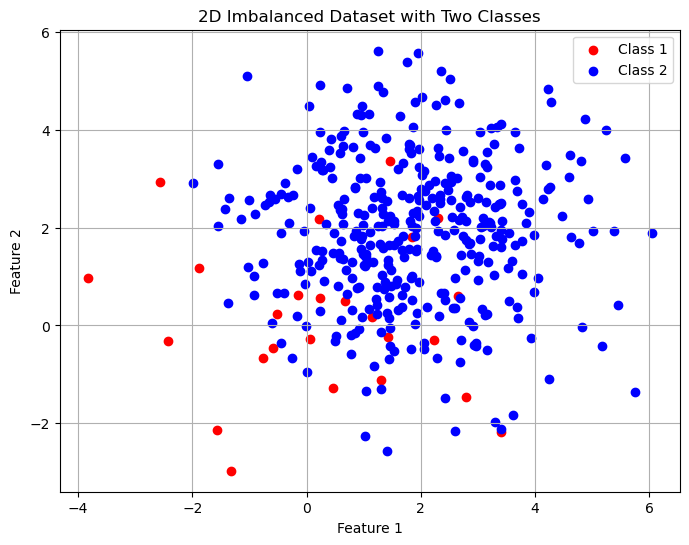

In [6]:

# Set random seed for reproducibility
np.random.seed(42)

# Generate imbalanced dataset
n_samples_1 = 25  # Number of samples in class 1
n_samples_2 = 375  # Number of samples in class 2
centers = [(0, 0), (2, 2)]  # Centers of each cluster
cluster_std = [1.5, 1.5]  # Standard deviation of each cluster

X, Y = make_blobs(n_samples=[n_samples_1, n_samples_2],
                  centers=centers,
                  cluster_std=cluster_std,
                  random_state=0)

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X[Y == 0][:, 0], X[Y == 0][:, 1], color='red', label='Class 1')
plt.scatter(X[Y == 1][:, 0], X[Y == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


The above data is highly imbalanced. Lets see the impact of classification on an imbalanced dataset.

In [5]:
from sklearn.linear_model import LogisticRegression

In [7]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.7,random_state=42)

In [8]:
classifier=LogisticRegression()

In [9]:
classifier.fit(X_train,Y_train)

LogisticRegression()

In [13]:
Y_pred=classifier.predict(X_test)
Y_proba=classifier.predict_proba(X_test)[:,1] #gives probabilites of classes

In [18]:
print("classification report")
pd.DataFrame(classification_report(Y_test,Y_pred,output_dict=True)).T

classification report


,precision,recall,f1-score,support
0,1.000000,0.285714,0.444444,7.000000
1,0.957627,1.000000,0.978355,113.000000
accuracy,0.958333,0.958333,0.958333,0.958333
macro avg,0.978814,0.642857,0.711400,120.000000
weighted avg,0.960099,0.958333,0.947210,120.000000


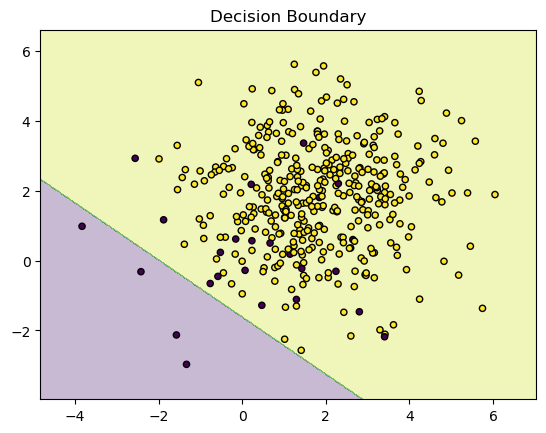

In [19]:
#Plotting decision Boundary
# Function to plot decision boundaries
def plot_decision_boundaries(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary")
    plt.show()

# Plot decision boundary
plot_decision_boundaries(X, y, classifier)


From above figure it is clear that our model is trying very hard to alteast not make mistake in classifying majority class.

In [20]:
print("classification report")
pd.DataFrame(classification_report(Y_test,Y_pred,output_dict=True)).T

classification report


,precision,recall,f1-score,support
0,1.000000,0.285714,0.444444,7.000000
1,0.957627,1.000000,0.978355,113.000000
accuracy,0.958333,0.958333,0.958333,0.958333
macro avg,0.978814,0.642857,0.711400,120.000000
weighted avg,0.960099,0.958333,0.947210,120.000000


Recall for minority class is very bad 0.28. Our model is very bad at classifying minority class but still accuracy is very good.

Techniques for handling imbalanced dataset
1. Over Sampling
2. Under Sampling
3. SMOTE
4. Ensemble Learning
5. Cost Sensitive Learning

<h3>Under Sampling-> Reduce data points from majority class untill they are equal to minority class.</h3>

In [26]:
#library-> imblearn -> imbalanced learn
from imblearn.under_sampling import RandomUnderSampler

In [23]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [24]:
rus=RandomUnderSampler(random_state=42)

In [25]:
X_resampled,Y_resampled=rus.fit_resample(X_train,Y_train)

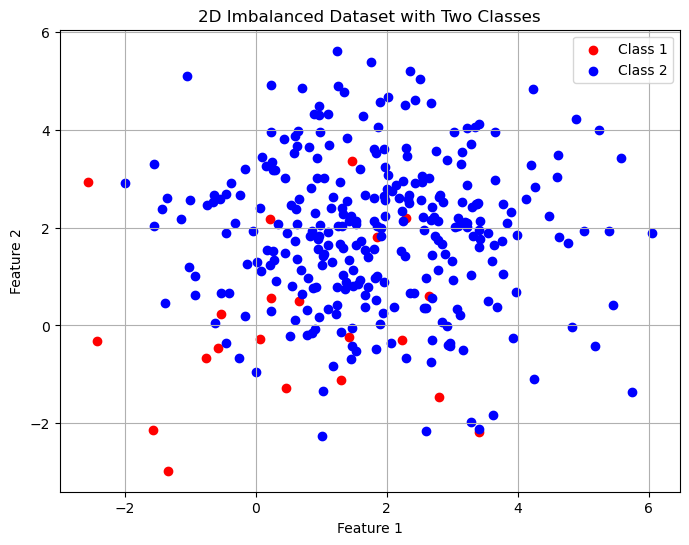

In [28]:

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train[Y_train == 0][:, 0], X_train[Y_train == 0][:, 1], color='red', label='Class 1')
plt.scatter(X_train[Y_train == 1][:, 0], X_train[Y_train == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


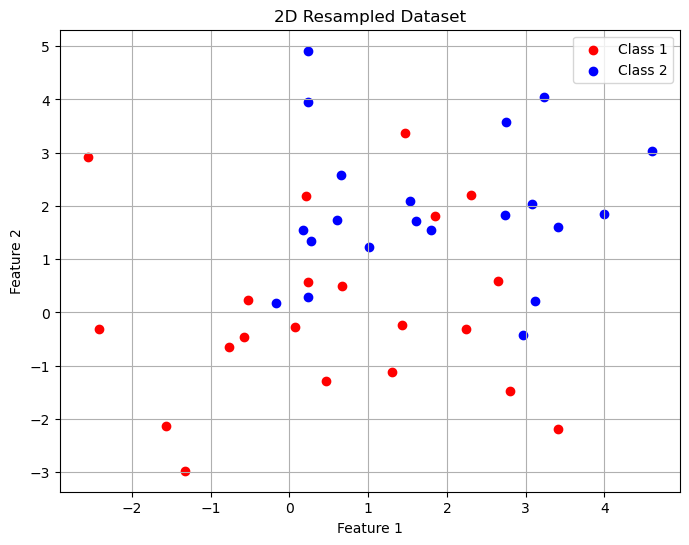

In [29]:

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_resampled[Y_resampled == 0][:, 0], X_resampled[Y_resampled == 0][:, 1], color='red', label='Class 1')
plt.scatter(X_resampled[Y_resampled == 1][:, 0], X_resampled[Y_resampled == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Resampled Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
pd.Series(Y_train).value_counts()

1    299
0     21
Name: count, dtype: int64

In [31]:
pd.Series(Y_resampled).value_counts()

0    21
1    21
Name: count, dtype: int64

In [32]:
classifier_rus=LogisticRegression()
classifier_rus.fit(X_resampled,Y_resampled)

LogisticRegression()

In [34]:
Y_predict_resampled=classifier_rus.predict(X_test)
Y_proba_resampled=classifier_rus.predict_proba(X_test)[:,1]

In [36]:
print(f'classification report with Over Sampling')
print(classification_report(Y_test,Y_predict_resampled))

classification report with Over Sampling
              precision    recall  f1-score   support

           0       0.18      1.00      0.31         4
           1       1.00      0.76      0.87        76

    accuracy                           0.78        80
   macro avg       0.59      0.88      0.59        80
weighted avg       0.96      0.78      0.84        80



now recall is good.

ROC AUC Score (With Random Under Sampling): 0.9375


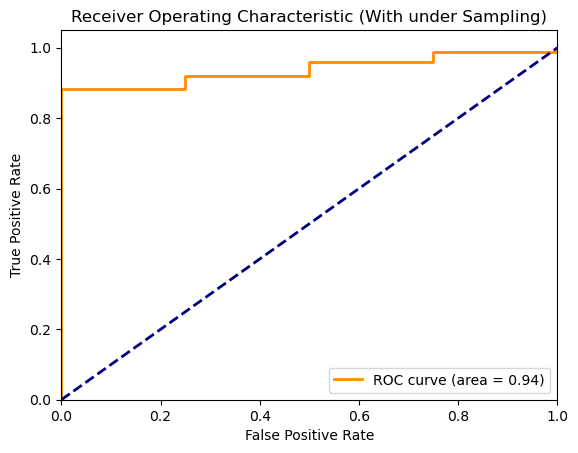

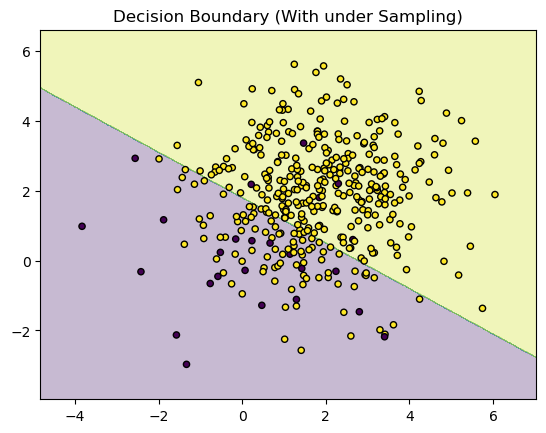

In [42]:

# Print ROC AUC Score for resampled data
print("ROC AUC Score (With Random Under Sampling):", roc_auc_score(Y_test, Y_proba_resampled))

# Plotting ROC AUC Curve for resampled data
fpr_rus, tpr_rus, _ = roc_curve(Y_test, Y_proba_resampled)
plt.figure()
plt.plot(fpr_rus, tpr_rus, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(Y_test, Y_proba_resampled))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With under Sampling)')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for resampled data
def plot_decision_boundaries_ros(X, Y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With under Sampling)")
    plt.show()

# Plot decision boundary for resampled data
plot_decision_boundaries_ros(X, Y, classifier_rus)


<h3>Over Sampling -> Increase the minority class</h3>

Random Over Sampling

In [43]:
from imblearn.over_sampling import RandomOverSampler

In [44]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.80,random_state=42)

In [45]:
ros=RandomOverSampler(random_state=42)

In [46]:
X_resampled,Y_resampled=ros.fit_resample(X_train,Y_train)

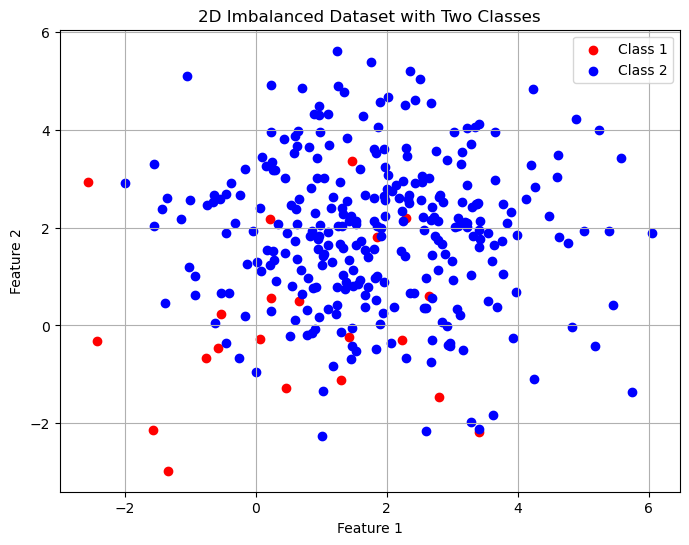

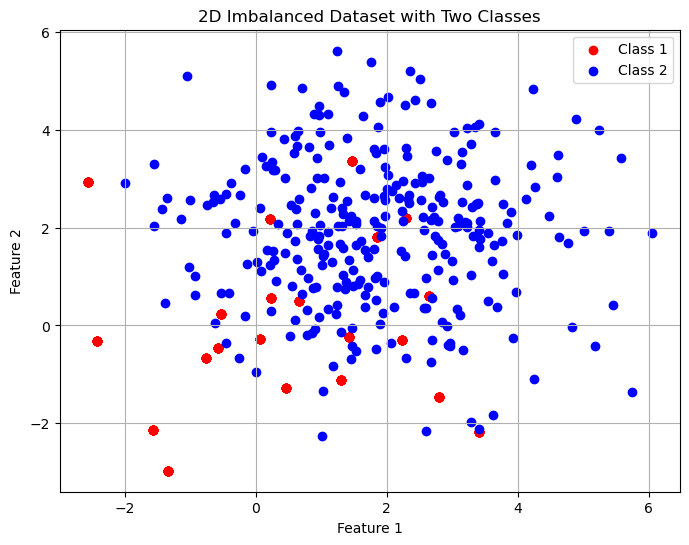

In [47]:

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train[Y_train == 0][:, 0], X_train[Y_train == 0][:, 1], color='red', label='Class 1')
plt.scatter(X_train[Y_train == 1][:, 0], X_train[Y_train == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_resampled[Y_resampled == 0][:, 0], X_resampled[Y_resampled == 0][:, 1], color='red', label='Class 1')
plt.scatter(X_resampled[Y_resampled == 1][:, 0], X_resampled[Y_resampled == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

We are not able to see inc in points due to over lapping over one another

In [48]:
X_resampled.shape

(598, 2)

In [49]:
X_train.shape

(320, 2)

In [51]:
pd.Series(Y_train).value_counts()

1    299
0     21
Name: count, dtype: int64

In [52]:
pd.Series(Y_resampled).value_counts()

1    299
0    299
Name: count, dtype: int64

Classification Report (With Over Sampling):
              precision    recall  f1-score   support

           0       0.18      1.00      0.31         4
           1       1.00      0.76      0.87        76

    accuracy                           0.78        80
   macro avg       0.59      0.88      0.59        80
weighted avg       0.96      0.78      0.84        80

ROC AUC Score (With Over Sampling): 0.950657894736842


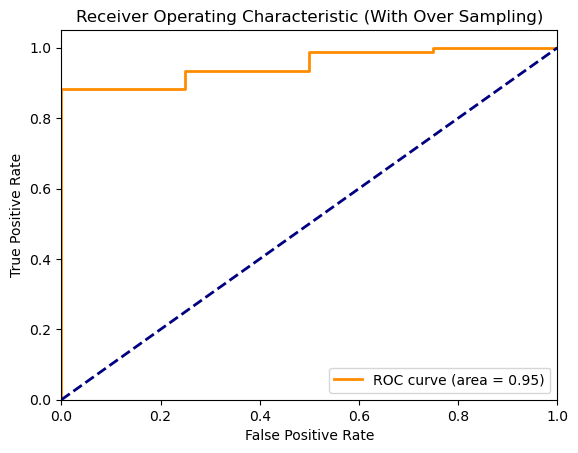

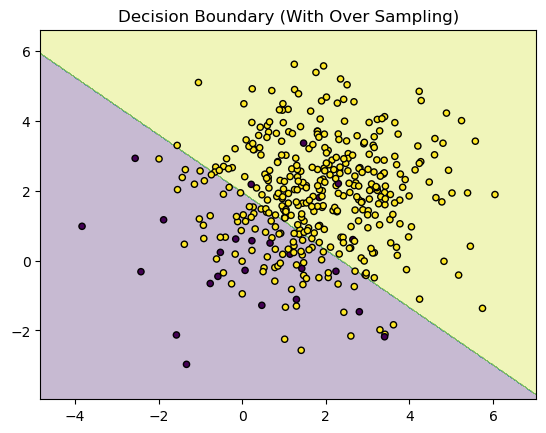

In [53]:
# Initialize and train RandomForest classifier on resampled data
classifier_ros = LogisticRegression()
classifier_ros.fit(X_resampled, Y_resampled)

# Predict test set
y_pred_ros = classifier_ros.predict(X_test)
y_proba_ros = classifier_ros.predict_proba(X_test)[:, 1]

# Print classification report for resampled data
print("Classification Report (With Over Sampling):")
print(classification_report(Y_test, y_pred_ros))

# Print ROC AUC Score for resampled data
print("ROC AUC Score (With Over Sampling):", roc_auc_score(Y_test, y_proba_ros))

# Plotting ROC AUC Curve for resampled data
fpr_ros, tpr_ros, _ = roc_curve(Y_test, y_proba_ros)
plt.figure()
plt.plot(fpr_ros, tpr_ros, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(Y_test, y_proba_ros))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With Over Sampling)')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for resampled data
def plot_decision_boundaries_ros(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With Over Sampling)")
    plt.show()

# Plot decision boundary for resampled data
plot_decision_boundaries_ros(X, Y, classifier_ros)


This technique may lead to over fitting

<h5>SMOTE Synthetic Minority Over Sampling</h5>

<p>The main difference between SMOTE and random over sampling is
    <br>
Random over sampling-> just repeats the data of minority for inc in class but the issue here is of over fitting.
    <br>
Smote-> generates new data points for inc in minority class.</p>

In [55]:
from imblearn.over_sampling import SMOTE

In [56]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [57]:
smote=SMOTE(random_state=42)

In [58]:
X_resampled_smote,Y_resampled_smote=smote.fit_resample(X_train,Y_train)

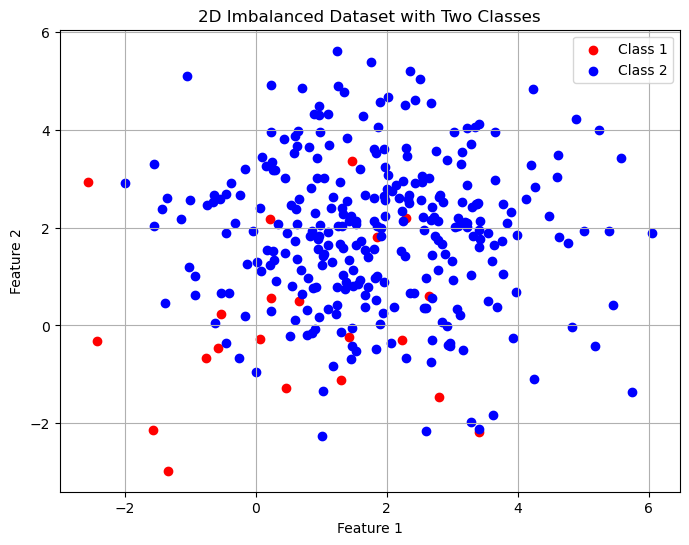

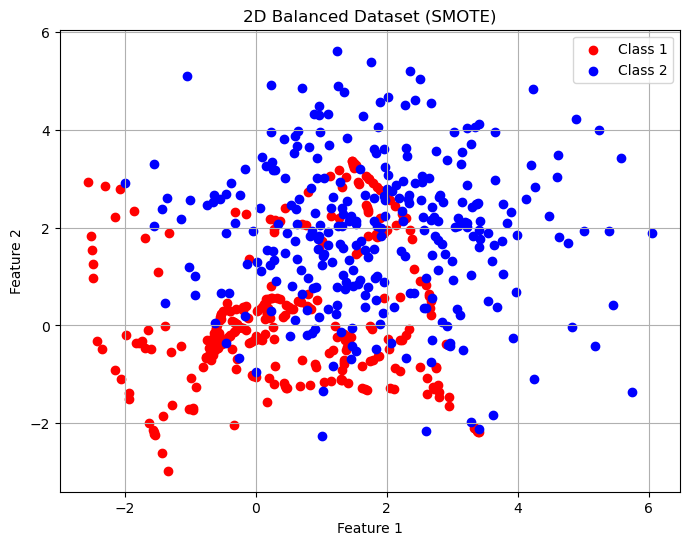

In [60]:

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train[Y_train == 0][:, 0], X_train[Y_train == 0][:, 1], color='red', label='Class 1')
plt.scatter(X_train[Y_train == 1][:, 0], X_train[Y_train == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_resampled_smote[Y_resampled_smote == 0][:, 0], X_resampled_smote[Y_resampled_smote == 0][:, 1], color='red', label='Class 1')
plt.scatter(X_resampled_smote[Y_resampled_smote == 1][:, 0], X_resampled_smote[Y_resampled_smote == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Balanced Dataset (SMOTE)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [61]:
X_resampled_smote.shape

(598, 2)

In [63]:
pd.Series(Y_resampled_smote).value_counts()

1    299
0    299
Name: count, dtype: int64

Classification Report (With SMOTE):
              precision    recall  f1-score   support

           0       0.17      1.00      0.30         4
           1       1.00      0.75      0.86        76

    accuracy                           0.76        80
   macro avg       0.59      0.88      0.58        80
weighted avg       0.96      0.76      0.83        80

ROC AUC Score (With SMOTE): 0.950657894736842


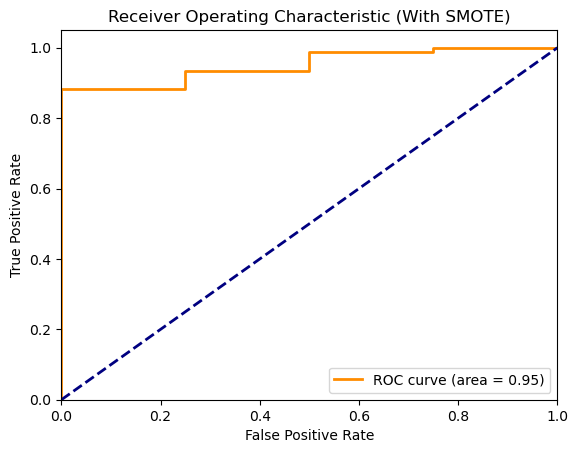

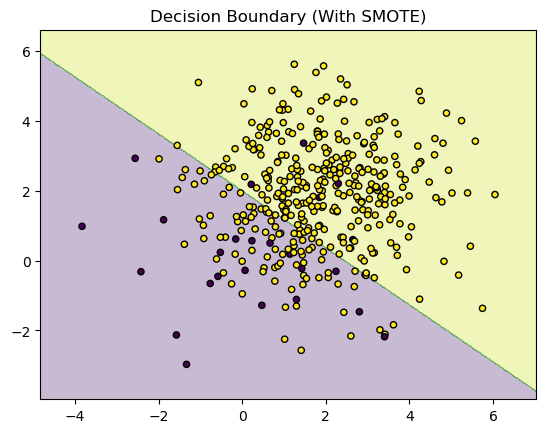

In [64]:
# Initialize and train RandomForest classifier on resampled data
classifier_smote = LogisticRegression()
classifier_smote.fit(X_resampled_smote, Y_resampled_smote)

# Predict test set
y_pred_smote = classifier_smote.predict(X_test)
y_proba_smote = classifier_smote.predict_proba(X_test)[:, 1]

# Print classification report for SMOTE data
print("Classification Report (With SMOTE):")
print(classification_report(Y_test, y_pred_smote))

# Print ROC AUC Score for SMOTE data
print("ROC AUC Score (With SMOTE):", roc_auc_score(Y_test, y_proba_smote))

# Plotting ROC AUC Curve for SMOTE data
fpr_smote, tpr_smote, _ = roc_curve(Y_test, y_proba_smote)
plt.figure()
plt.plot(fpr_smote, tpr_smote, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(Y_test, y_proba_smote))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With SMOTE)')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for SMOTE data
def plot_decision_boundaries_smote(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With SMOTE)")
    plt.show()

# Plot decision boundary for SMOTE data
plot_decision_boundaries_smote(X, y, classifier_smote)

Ensemble Methods

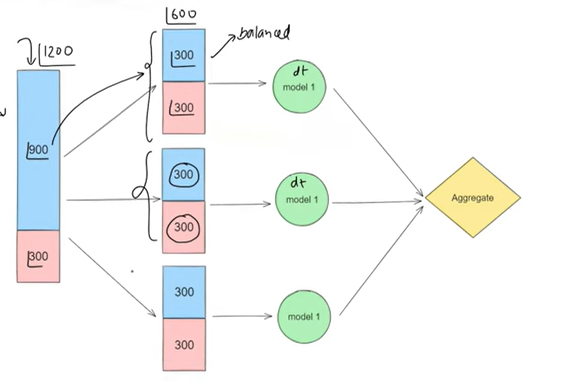

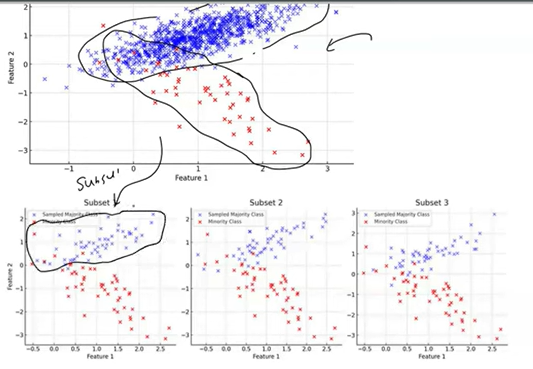!

C:\Users\Dell\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:546: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\Dell\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:558: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(


Classification Report (With SMOTE):
              precision    recall  f1-score   support

           0       0.16      0.75      0.26         4
           1       0.98      0.79      0.88        76

    accuracy                           0.79        80
   macro avg       0.57      0.77      0.57        80
weighted avg       0.94      0.79      0.85        80

ROC AUC Score (With SMOTE): 0.8519736842105262


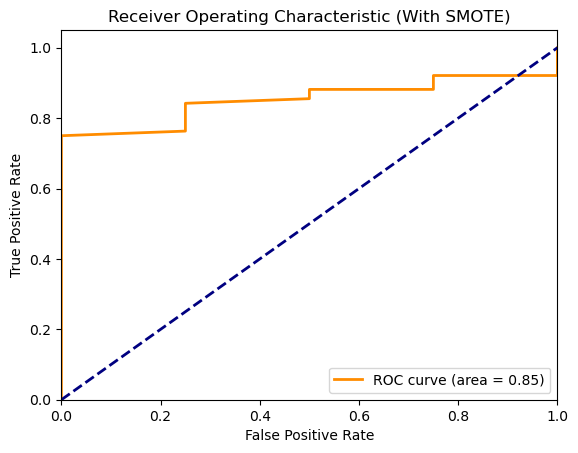

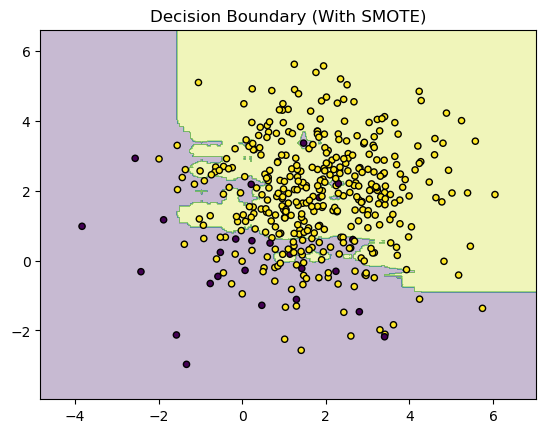

In [66]:
from imblearn.ensemble import BalancedRandomForestClassifier

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Applying SMOTE
classifier = BalancedRandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

# Predict test set
y_pred_brf = classifier.predict(X_test)
y_proba_brf = classifier.predict_proba(X_test)[:, 1]

# Print classification report for SMOTE data
print("Classification Report (With SMOTE):")
print(classification_report(y_test, y_pred_brf))

# Print ROC AUC Score for SMOTE data
print("ROC AUC Score (With SMOTE):", roc_auc_score(y_test, y_proba_brf))

# Plotting ROC AUC Curve for SMOTE data
fpr_brf, tpr_brf, _ = roc_curve(y_test, y_proba_brf)
plt.figure()
plt.plot(fpr_brf, tpr_brf, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_brf))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With SMOTE)')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for SMOTE data
def plot_decision_boundaries_smote(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With SMOTE)")
    plt.show()

# Plot decision boundary for SMOTE data
plot_decision_boundaries_smote(X, y, classifier)